In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

### Meteorites

In [41]:
df = pd.read_csv("data/meteorite_landings.csv")

In [42]:
print("Podstawowe informacje o zbiorze:")
print(df.info())
print("\nPrzykładowe dane:")
print(df.head())

Podstawowe informacje o zbiorze:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45716 entries, 0 to 45715
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         45716 non-null  object 
 1   id           45716 non-null  int64  
 2   nametype     45716 non-null  object 
 3   recclass     45716 non-null  object 
 4   mass (g)     45585 non-null  float64
 5   fall         45716 non-null  object 
 6   year         45425 non-null  float64
 7   reclat       38401 non-null  float64
 8   reclong      38401 non-null  float64
 9   GeoLocation  38401 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 3.5+ MB
None

Przykładowe dane:
       name   id nametype     recclass  mass (g)  fall    year    reclat  \
0    Aachen    1    Valid           L5      21.0  Fell  1880.0  50.77500   
1    Aarhus    2    Valid           H6     720.0  Fell  1951.0  56.18333   
2      Abee    6    Valid          EH4  

In [43]:
print("Statystyki opisowe:")
print(df.describe(include='all'))

Statystyki opisowe:
          name            id nametype recclass      mass (g)   fall  \
count    45716  45716.000000    45716    45716  4.558500e+04  45716   
unique   45716           NaN        2      466           NaN      2   
top     Aachen           NaN    Valid       L6           NaN  Found   
freq         1           NaN    45641     8285           NaN  44609   
mean       NaN  26889.735104      NaN      NaN  1.327808e+04    NaN   
std        NaN  16860.683030      NaN      NaN  5.749889e+05    NaN   
min        NaN      1.000000      NaN      NaN  0.000000e+00    NaN   
25%        NaN  12688.750000      NaN      NaN  7.200000e+00    NaN   
50%        NaN  24261.500000      NaN      NaN  3.260000e+01    NaN   
75%        NaN  40656.750000      NaN      NaN  2.026000e+02    NaN   
max        NaN  57458.000000      NaN      NaN  6.000000e+07    NaN   

                year        reclat       reclong GeoLocation  
count   45425.000000  38401.000000  38401.000000       38401  
u

In [44]:
print("Brakujące wartości:")
print(df.isnull().sum())

Brakujące wartości:
name              0
id                0
nametype          0
recclass          0
mass (g)        131
fall              0
year            291
reclat         7315
reclong        7315
GeoLocation    7315
dtype: int64


#### Boxplot masy meteorytów

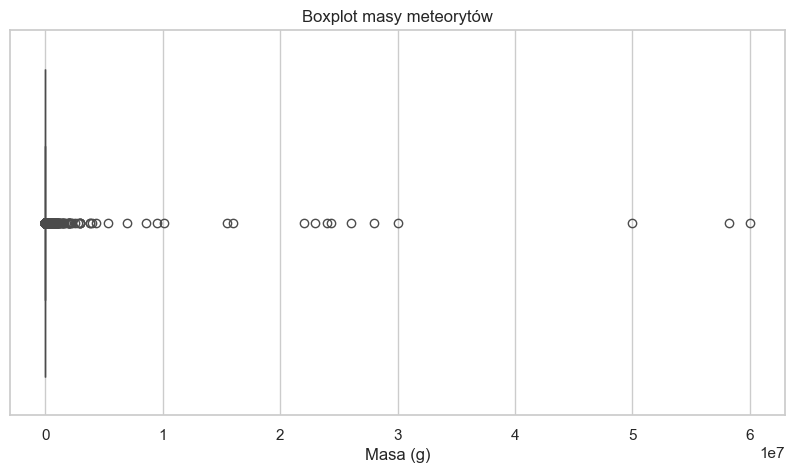

In [45]:
plt.figure()
sns.boxplot(x=df['mass (g)'])
plt.title('Boxplot masy meteorytów')
plt.xlabel('Masa (g)')
plt.show()

#### Histogramy zmiennych liczbowych

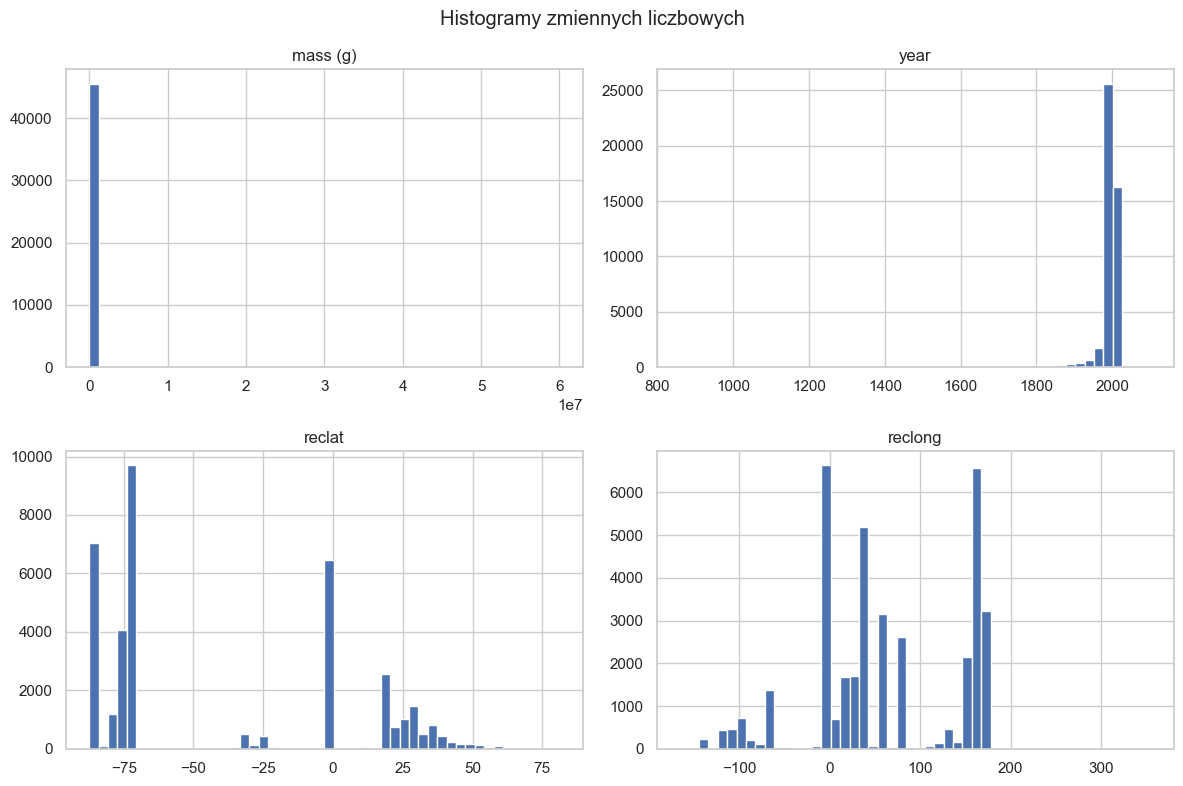

In [46]:
df[['mass (g)', 'year', 'reclat', 'reclong']].hist(bins=50, figsize=(12, 8), grid=True)
plt.suptitle('Histogramy zmiennych liczbowych')
plt.tight_layout()
plt.show()

#### Macierz korelacji

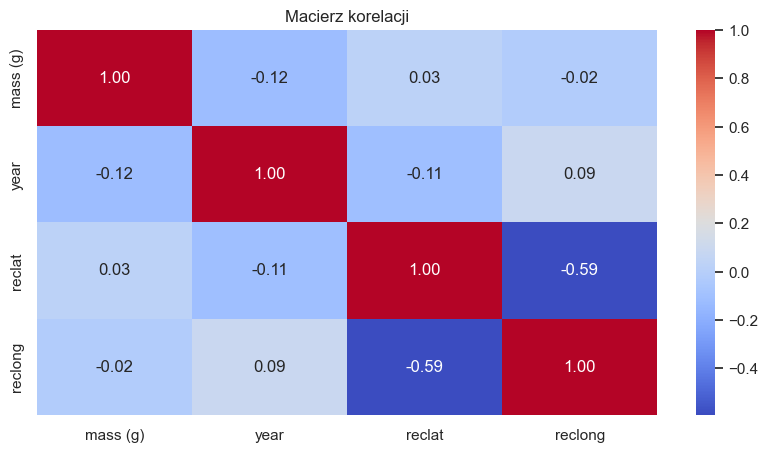

In [47]:
corr = df[['mass (g)', 'year', 'reclat', 'reclong']].corr()
plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Macierz korelacji')
plt.show()

#### Boxplot masy wg. kategorii Fell vs Found

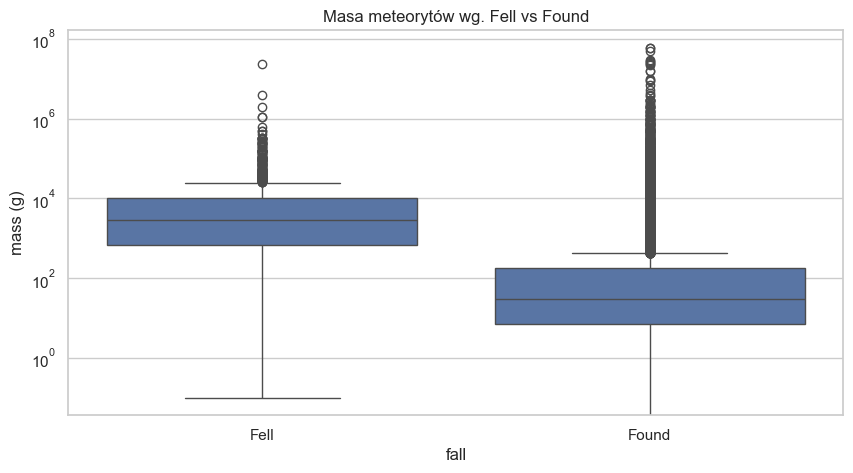

In [48]:
plt.figure()
sns.boxplot(data=df, x='fall', y='mass (g)')
plt.title('Masa meteorytów wg. Fell vs Found')
plt.yscale("log")
plt.show()

#### Scatterplot: mass (g) vs year

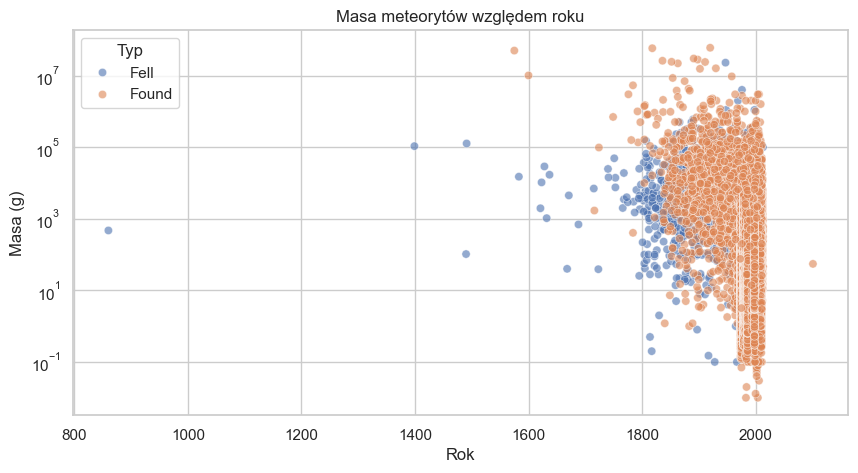

In [49]:
plt.figure()
sns.scatterplot(data=df, x='year', y='mass (g)', hue='fall', alpha=0.6)
plt.yscale('log')
plt.title('Masa meteorytów względem roku')
plt.xlabel('Rok')
plt.ylabel('Masa (g)')
plt.legend(title='Typ')
plt.show()

### Fireballs and Bolides

In [27]:
df = pd.read_csv("data/fireball_and_bolide_reports.csv", sep=";")

In [28]:
print("Informacje o zbiorze:")
print(df.info())
print("\nPrzykładowe dane:")
print(df.head())

Informacje o zbiorze:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 10 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Date/Time                           986 non-null    object 
 1   Radiated Energy (e10 J)             986 non-null    float64
 2   Impact energy (kt)                  986 non-null    float64
 3   Velocity (km/s)                     305 non-null    float64
 4   Altitude (km)                       527 non-null    float64
 5   Longitude (deg.)                    796 non-null    float64
 6   Latitude (deg.)                     796 non-null    float64
 7   Latitude direction (East / West)    796 non-null    object 
 8   Latitude direction (North / South)  796 non-null    object 
 9   Geo point                           796 non-null    object 
dtypes: float64(6), object(4)
memory usage: 77.2+ KB
None

Przykładowe dane:
                

In [29]:
print("Statystyki opisowe:")
print(df.describe(include='all'))

Statystyki opisowe:
                        Date/Time  Radiated Energy (e10 J)  \
count                         986               986.000000   
unique                        986                      NaN   
top     2024-05-05T22:11:03+02:00                      NaN   
freq                            1                      NaN   
mean                          NaN                72.891481   
std                           NaN              1204.910806   
min                           NaN                 2.000000   
25%                           NaN                 3.200000   
50%                           NaN                 6.200000   
75%                           NaN                14.475000   
max                           NaN             37500.000000   

        Impact energy (kt)  Velocity (km/s)  Altitude (km)  Longitude (deg.)  \
count           986.000000       305.000000     527.000000        796.000000   
unique                 NaN              NaN            NaN               Na

In [30]:
print("Brakujące wartości:")
print(df.isnull().sum())

Brakujące wartości:
Date/Time                               0
Radiated Energy (e10 J)                 0
Impact energy (kt)                      0
Velocity (km/s)                       681
Altitude (km)                         459
Longitude (deg.)                      190
Latitude (deg.)                       190
Latitude direction (East / West)      190
Latitude direction (North / South)    190
Geo point                             190
dtype: int64


#### Boxploty dla wybranych zmiennych liczbowych

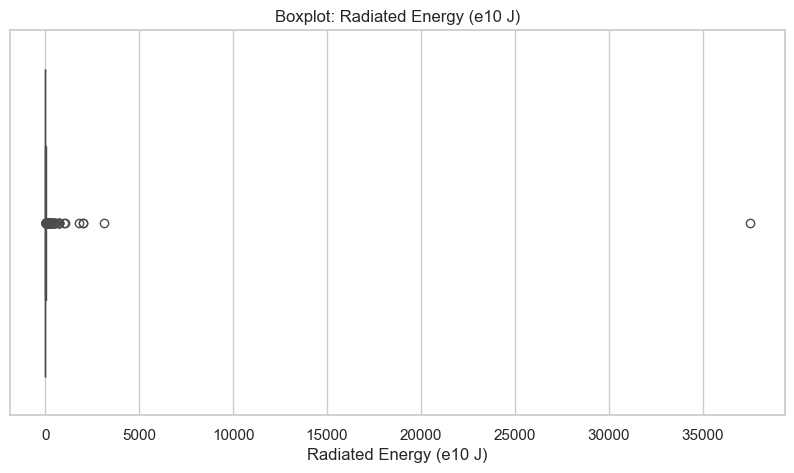

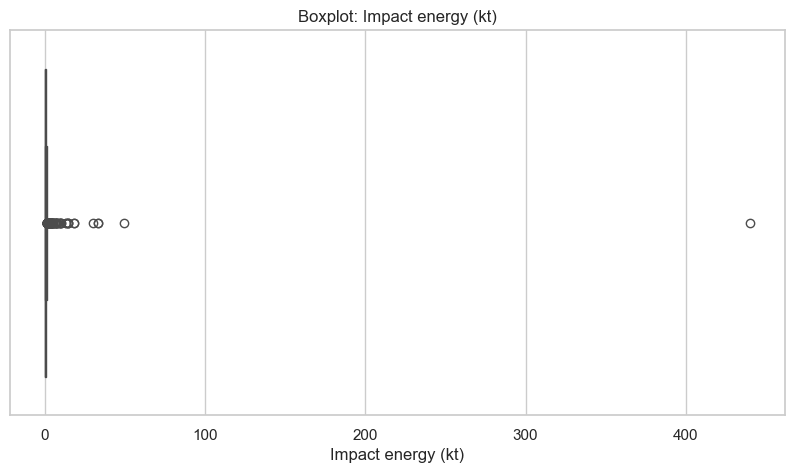

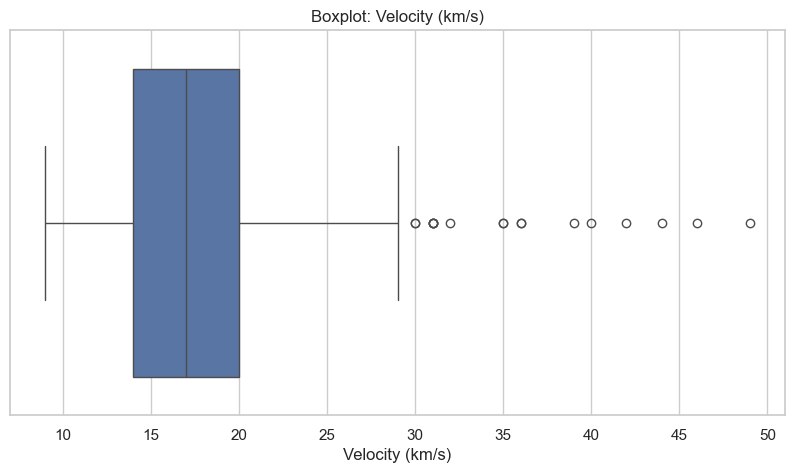

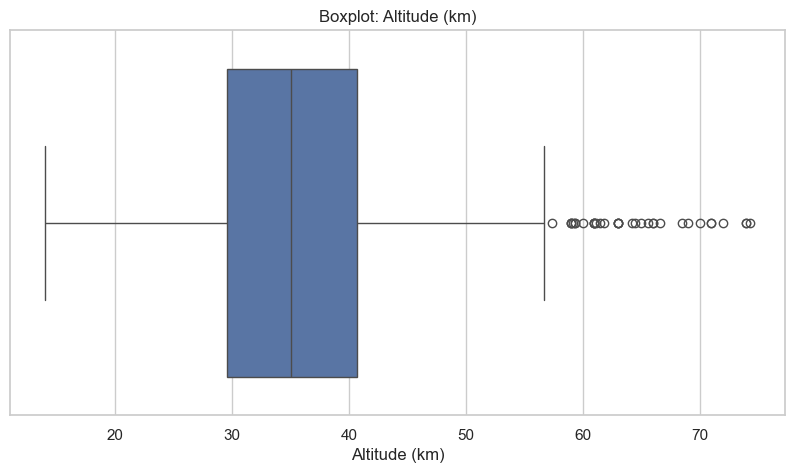

In [31]:
num_cols = ['Radiated Energy (e10 J)', 'Impact energy (kt)', 'Velocity (km/s)', 'Altitude (km)']
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

#### Histogramy zmiennych liczbowych

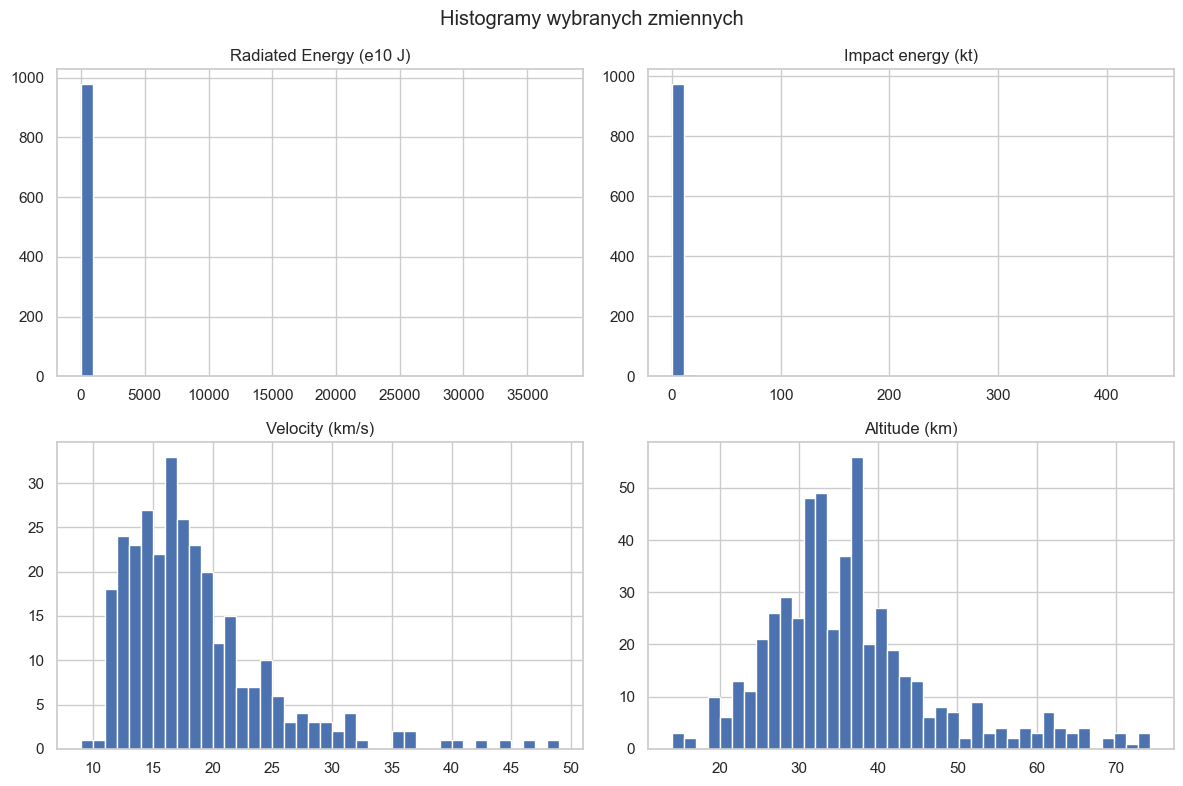

In [32]:
df[num_cols].hist(bins=40, figsize=(12, 8), grid=True)
plt.suptitle("Histogramy wybranych zmiennych")
plt.tight_layout()
plt.show()

#### Macierz korelacji

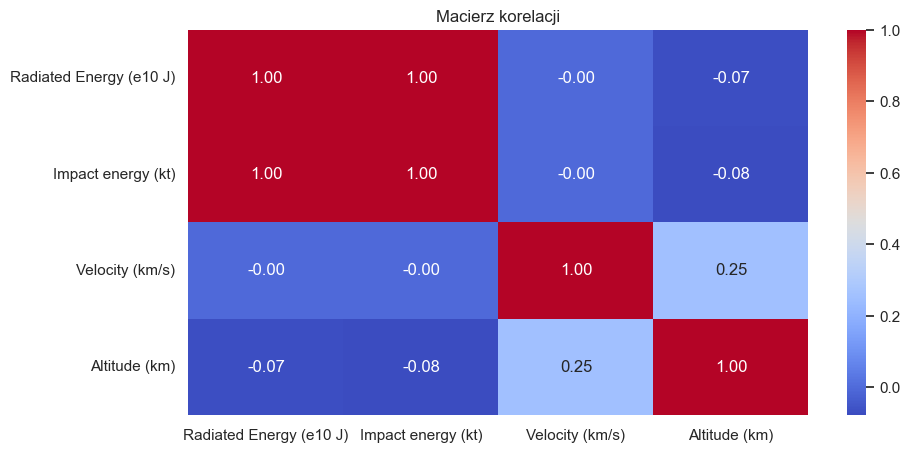

In [33]:
plt.figure()
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Macierz korelacji")
plt.show()

#### Scatterplot: Velocity vs Impact energy

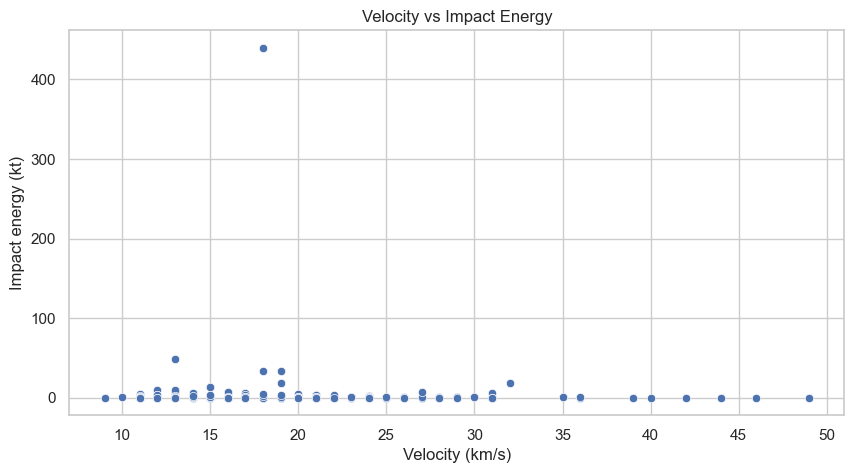

In [34]:
plt.figure()
sns.scatterplot(data=df, x="Velocity (km/s)", y="Impact energy (kt)")
plt.title("Velocity vs Impact Energy")
plt.show()

### Near Earth Objects

In [5]:
df = pd.read_csv("data/nearest_earth_objects.csv")

In [6]:
print("Informacje o zbiorze:")
print(df.info())
print("\nPrzykładowe dane:")
print(df.head())

Informacje o zbiorze:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB
None

Przykładowe dane:
        id                 name  est_diameter_min  est_diameter_max  \
0  2162635  162635 (2000 SS164)          1.198271          2.679415   
1  2277475    277475 (2005 WK4)          0.2

In [7]:
print("\nStatystyki opisowe:")
print(df.describe())


Statystyki opisowe:
                 id  est_diameter_min  est_diameter_max  relative_velocity  \
count  9.083600e+04      90836.000000      90836.000000       90836.000000   
mean   1.438288e+07          0.127432          0.284947       48066.918918   
std    2.087202e+07          0.298511          0.667491       25293.296961   
min    2.000433e+06          0.000609          0.001362         203.346433   
25%    3.448110e+06          0.019256          0.043057       28619.020645   
50%    3.748362e+06          0.048368          0.108153       44190.117890   
75%    3.884023e+06          0.143402          0.320656       62923.604633   
max    5.427591e+07         37.892650         84.730541      236990.128088   

       miss_distance  absolute_magnitude  
count   9.083600e+04        90836.000000  
mean    3.706655e+07           23.527103  
std     2.235204e+07            2.894086  
min     6.745533e+03            9.230000  
25%     1.721082e+07           21.340000  
50%     3.784658e+

In [8]:
print("\nBrakujące wartości:")
print(df.isnull().sum())


Brakujące wartości:
id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64


#### Histogramy zmiennych liczbowych

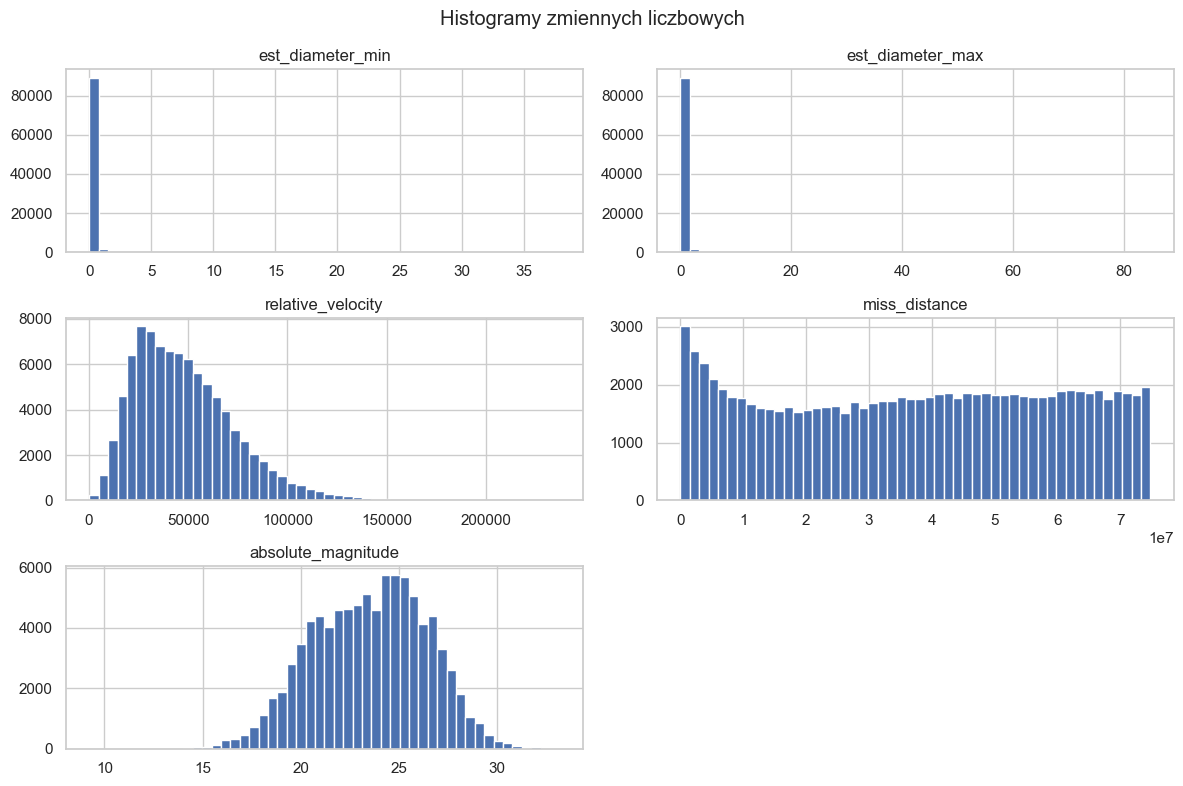

In [9]:
num_cols = [
    "est_diameter_min", "est_diameter_max", "relative_velocity",
    "miss_distance", "absolute_magnitude"
]
df[num_cols].hist(bins=50, figsize=(12, 8))
plt.suptitle("Histogramy zmiennych liczbowych")
plt.tight_layout()
plt.show()

#### Boxploty - analiza wartości odstających

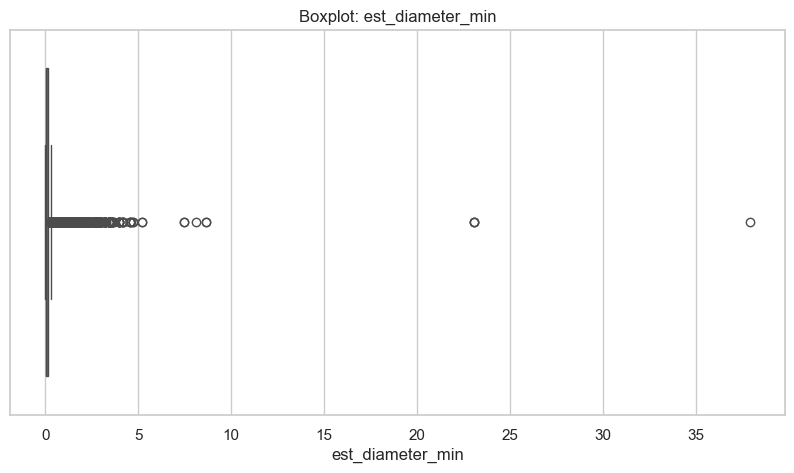

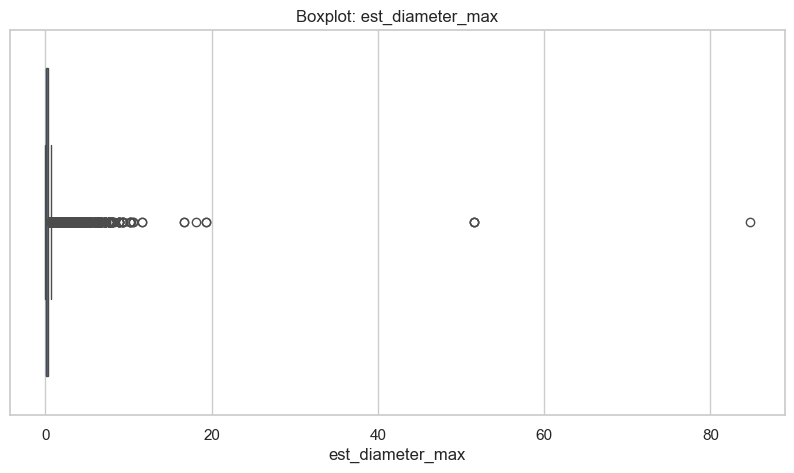

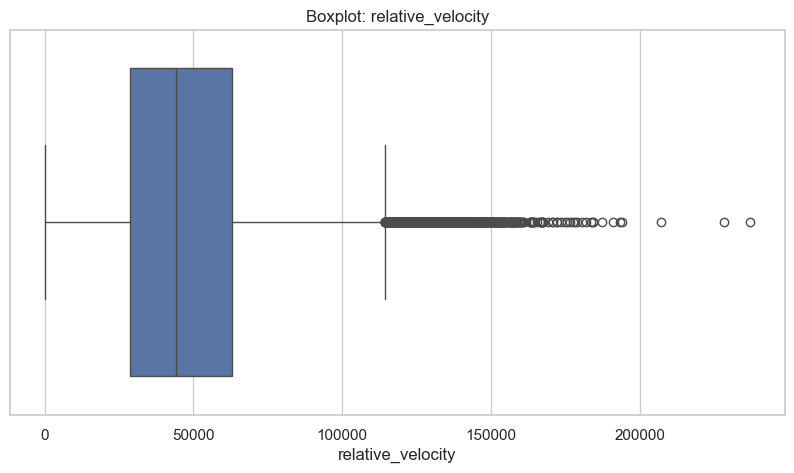

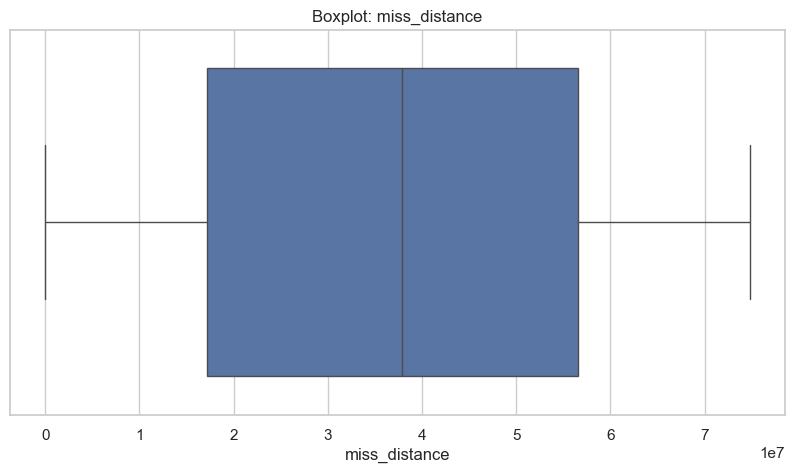

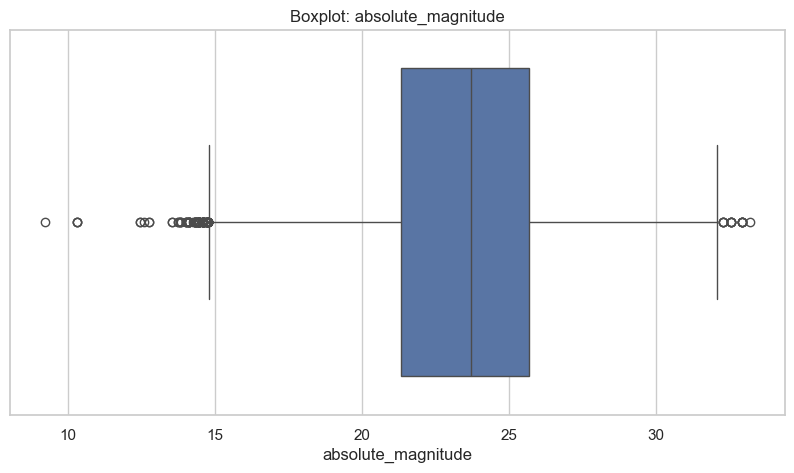

In [10]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

#### Macierz korelacji zmiennych liczbowych

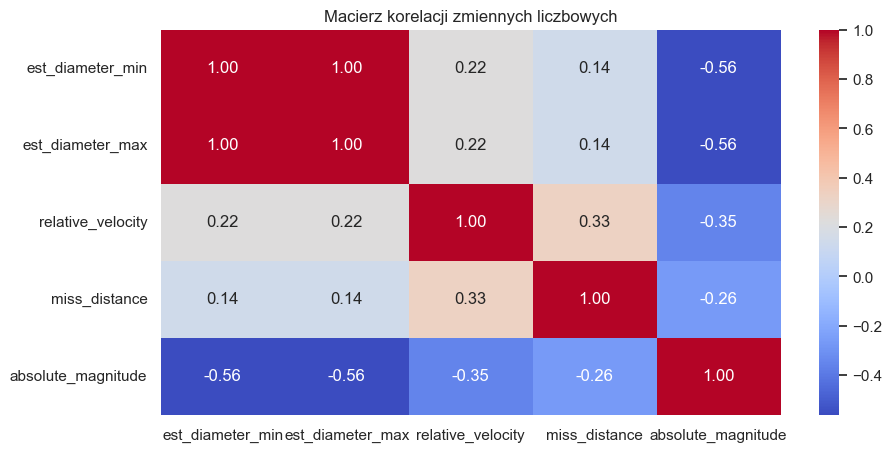

In [11]:
plt.figure()
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Macierz korelacji zmiennych liczbowych")
plt.show()

#### Scatterplot - Średnica vs Odległość

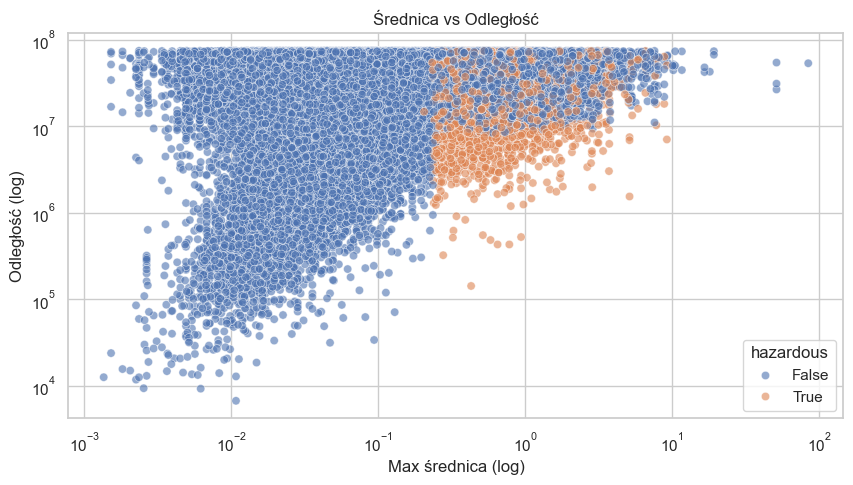

In [15]:
plt.figure()
sns.scatterplot(data=df, x="est_diameter_max", y="miss_distance", hue="hazardous", alpha=0.6)
plt.title("Średnica vs Odległość")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Max średnica (log)")
plt.ylabel("Odległość (log)")
plt.show()

#### Boxplot - Czy obiekty niebezpieczne są większe?

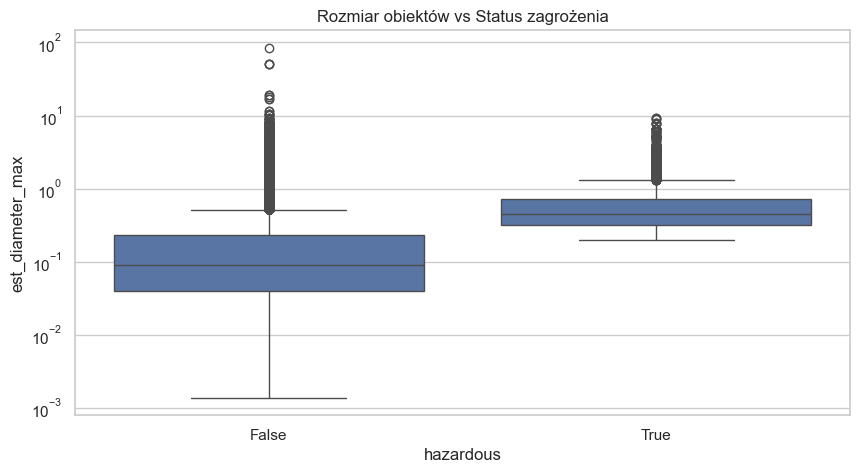

In [13]:
plt.figure()
sns.boxplot(data=df, x="hazardous", y="est_diameter_max")
plt.title("Rozmiar obiektów vs Status zagrożenia")
plt.yscale("log")
plt.show()